In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("devdgohil/the-oxfordiiit-pet-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset


In [2]:
import os

In [3]:
img_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images"
config_path = '/kaggle/working/config.json'
mask_path = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/annotations/annotations/trimaps"

In [4]:
print(len(os.listdir(img_path)))
print(len(os.listdir(mask_path)))

7393
14780


In [5]:
from torchvision import datasets, transforms as T
from torch.utils.data import DataLoader, Subset, random_split

def benchmark_num_workers(batch_size, img_size, num_workers_list=[0, 2, 4, 8]):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    transform = T.Compose([
        T.Resize(img_size),
        T.ToTensor()
    ])

    dataset = datasets.FakeData(transform=transform)

    results = {}
    for nw in num_workers_list:
        loader = DataLoader(dataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=nw,
                            pin_memory=(device == "cuda"))
        
        start = time.time()
        for i, batch in enumerate(loader):
            
            batch = batch[0].to(device, non_blocking=True)
            
            if i>50:
                break
        end = time.time()
        
        epoch_time = end - start
        results[nw] = epoch_time
        print(f"num_workers={nw} → epoch_time={epoch_time:.4f}s")

    best_nw = min(results, key=results.get)

    sorted_results = dict(sorted(results.items(),key=lambda kv: kv[1]))
    print(f"Benchmark: {sorted_results}")
    print(f"Selected: {best_nw}")

    return best_nw 

def load_config(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        config = json.load(f)

    return config

In [6]:
from dataclasses import dataclass

@dataclass
class Utils:

    CONFIG_PATH: str = "/kaggle/working/config.json"

    def __post_init__(self):

        self.CONFIG: dict = load_config(self.CONFIG_PATH)

In [7]:
!pip install git+https://github.com/ChaoningZhang/MobileSAM.git

  Cloning https://github.com/ChaoningZhang/MobileSAM.git to /tmp/pip-req-build-2f4gzhuh
  Running command git clone --filter=blob:none --quiet https://github.com/ChaoningZhang/MobileSAM.git /tmp/pip-req-build-2f4gzhuh
  Resolved https://github.com/ChaoningZhang/MobileSAM.git to commit b01a9ccef3b9e10b099b544efe004d0871802c3b
  Preparing metadata (setup.py) ... done
  Created wheel for mobile_sam: filename=mobile_sam-1.0-py3-none-any.whl size=42431 sha256=b3a885db90bf23600aa10adf2029c8de9b34b27393e961ec81197886eb7954d9
  Stored in directory: /tmp/pip-ephem-wheel-cache-14all7im/wheels/5f/88/d6/5c0b5d4d64a06e19190d50269d8725c8aeadb128c966801af5
Successfully built mobile_sam


In [8]:
import json

config = {}
def save_config(config, path):
    with open(path, 'w') as f:
        json.dump(config, f, indent=2)

save_config(config, config_path)

utils = Utils()
config = utils.CONFIG

In [9]:
    config.setdefault('images_dir',     img_path)
    config.setdefault('mask_dir',       mask_path)
    config.setdefault('checkpoint_dir', '/kaggle/working/checkpoints_sam')
    config.setdefault('best_model_dir', '/kaggle/working/best_model_sam')

    config.setdefault('sam_model_type', 'vit_t')      
    config.setdefault('sam_checkpoint', '/kaggle/input/models/dibyenducontroversy/mobile-sam/pytorch/default/1/mobile_sam.pt')

    # ── Data ──────────────────────────────────────────────────────────────────
    config.setdefault('img_size',    224)
    config.setdefault('max_samples', None)
    config.setdefault('split_size',  0.85)
    config.setdefault('cache_ram',   bool(0))

    # ── Training ──────────────────────────────────────────────────────────────
    # SAM image encoder is frozen but still heavy in memory — batch 4 is safe on T4
    config.setdefault('batch_size',      16)
    config.setdefault('max_iterations',  30)   # SAM fine-tunes fast
    config.setdefault('lr',              1e-4)  # lower LR — fine-tuning, not training from scratch
    config.setdefault('weight_decay',    1e-4)
    config.setdefault('grad_clip',       1.0)
    config.setdefault('accum_steps',     4)
    config.setdefault('patience',        8)
    config.setdefault('min_delta',       1e-4)
    config.setdefault('resume',          None)
    config.setdefault('save_every',      5)

    # ── Losses ────────────────────────────────────────────────────────────────
    config.setdefault('bce_weight',  0.4)
    config.setdefault('dice_weight', 0.4)
    config.setdefault('kl_weight',   0.2)

    config['num_workers'] = 4   # SAM is memory-heavy, keep workers low
    config['img_size'] = 1024
    save_config(config, utils.CONFIG_PATH)

In [10]:
load_config(config_path)

{'images_dir': '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images',
 'mask_dir': '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/annotations/annotations/trimaps',
 'checkpoint_dir': '/kaggle/working/checkpoints_sam',
 'best_model_dir': '/kaggle/working/best_model_sam',
 'sam_model_type': 'vit_t',
 'sam_checkpoint': '/kaggle/input/models/dibyenducontroversy/mobile-sam/pytorch/default/1/mobile_sam.pt',
 'img_size': 1024,
 'max_samples': None,
 'split_size': 0.85,
 'cache_ram': False,
 'batch_size': 16,
 'max_iterations': 30,
 'lr': 0.0001,
 'weight_decay': 0.0001,
 'grad_clip': 1.0,
 'accum_steps': 4,
 'patience': 8,
 'min_delta': 0.0001,
 'resume': None,
 'save_every': 5,
 'bce_weight': 0.4,
 'dice_weight': 0.4,
 'kl_weight': 0.2,
 'num_workers': 4}

In [14]:
!python /kaggle/input/models/dibyenducontroversy/asfasd/tensorflow2/default/1/train_seg_sam.py

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m

1. Loading MobileSAM on cuda...
2. Loading image: Abyssinian_1.jpg
3. Running inference...
4. Plotting results (Confidence Score: 0.986)...
5. Plot saved successfully to: /kaggle/working/sam_inference_plot.png


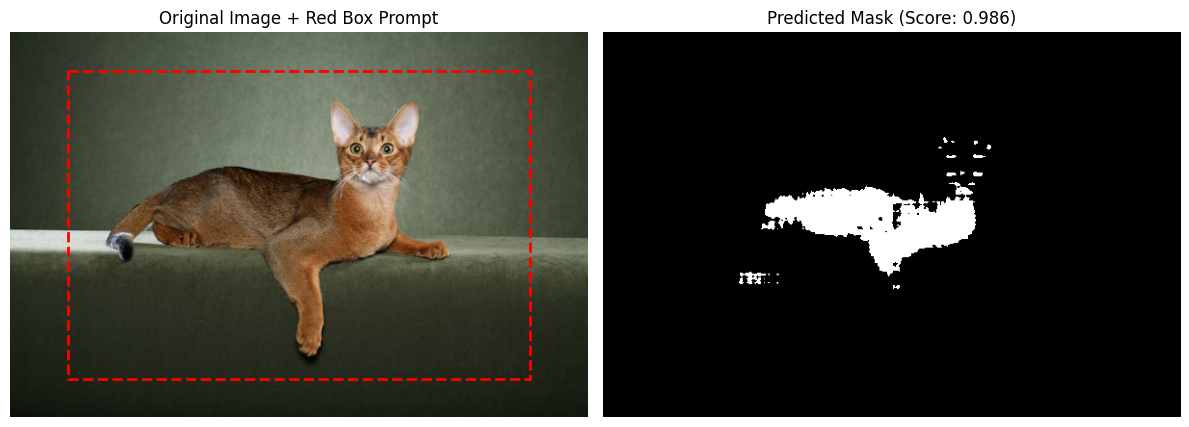

In [15]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from mobile_sam import sam_model_registry, SamPredictor

def predict_and_plot_sam(image_path, weights_path, save_path='/kaggle/working/sam_inference_plot.png'):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"1. Loading MobileSAM on {device}...")

    # 1. Load the fine-tuned SAM model
    sam = sam_model_registry['vit_t']()
    sam.load_state_dict(torch.load(weights_path, map_location=device))
    sam.to(device)
    sam.eval()

    # Use SamPredictor for automatic 1024x1024 resizing and padding!
    predictor = SamPredictor(sam)

    # 2. Load Image
    print(f"2. Loading image: {os.path.basename(image_path)}")
    image = Image.open(image_path).convert('RGB')
    image_np = np.array(image)
    H, W, _ = image_np.shape

    # 3. Set image in predictor
    predictor.set_image(image_np)

    # 4. Create Bounding Box Prompt (10% margin around the edges)
    margin_x = W * 0.10
    margin_y = H * 0.10
    box = np.array([
        margin_x,          # x_min
        margin_y,          # y_min
        W - margin_x,      # x_max
        H - margin_y       # y_max
    ])

    # 5. Predict
    print("3. Running inference...")
    masks, scores, _ = predictor.predict(
        box=box,
        multimask_output=True # Asks SAM for 3 mask proposals
    )

    # Pick the mask SAM is most confident about
    best_idx = np.argmax(scores)
    best_mask = masks[best_idx]
    best_score = scores[best_idx]

    # 6. Plotting
    print(f"4. Plotting results (Confidence Score: {best_score:.3f})...")
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot 1: Original Image with Bounding Box
    axes[0].imshow(image_np)
    rect = patches.Rectangle(
        (box[0], box[1]), box[2] - box[0], box[3] - box[1],
        linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
    )
    axes[0].add_patch(rect)
    axes[0].set_title("Original Image + Red Box Prompt")
    axes[0].axis('off')

    # Plot 2: Predicted Mask
    axes[1].imshow(best_mask, cmap='gray')
    axes[1].set_title(f"Predicted Mask (Score: {best_score:.3f})")
    axes[1].axis('off')

    plt.tight_layout()
    
    # Save the plot so you can view it in the Kaggle file explorer
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"5. Plot saved successfully to: {save_path}")
    
    # Display in notebook
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
#  EXECUTION
# ══════════════════════════════════════════════════════════════════════════════

img_path = '/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images/Abyssinian_1.jpg'
weights  = '/kaggle/working/best_model_sam/best_weights.pth'

predict_and_plot_sam(img_path, weights)

🎉 Loss plots successfully saved to: /kaggle/working/sam_loss_plots.png


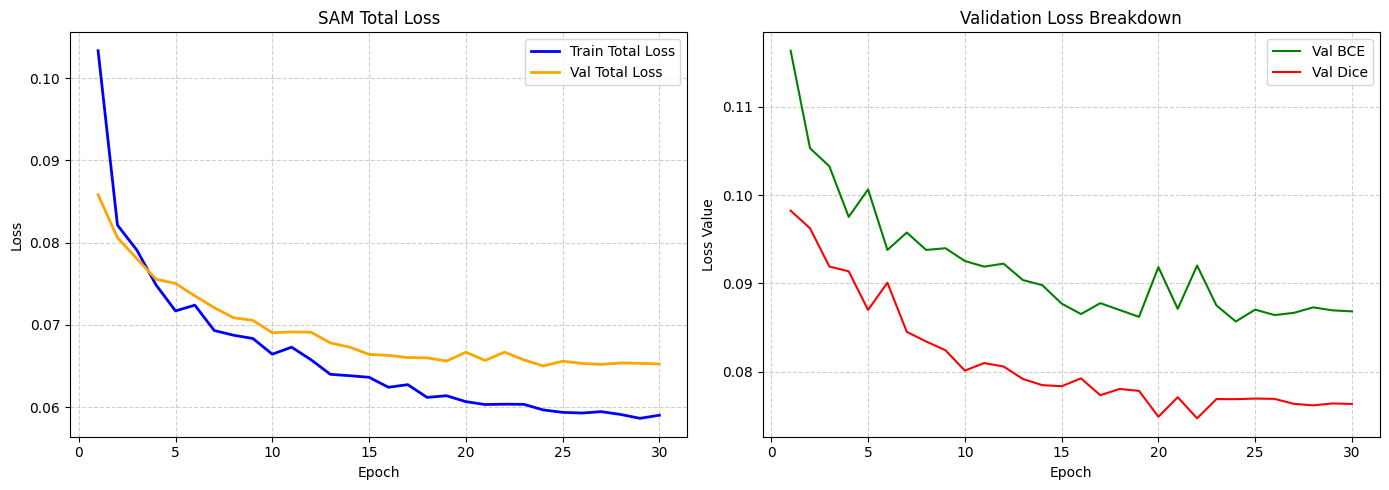

In [20]:
import os
import json
import matplotlib.pyplot as plt

def generate_and_save_loss_plots(
    history_path='/kaggle/working/checkpoints_sam/history.json', 
    save_path='/kaggle/working/sam_loss_plots.png'
):
    if not os.path.exists(history_path):
        print(f"❌ Error: Could not find {history_path}")
        return

    # Load the training history
    with open(history_path, 'r') as f:
        history = json.load(f)

    epochs = range(1, len(history['train_total']) + 1)

    # Create a nice wide figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Total Loss
    axes[0].plot(epochs, history['train_total'], label='Train Total Loss', color='blue', linewidth=2)
    axes[0].plot(epochs, history['val_total'], label='Val Total Loss', color='orange', linewidth=2)
    axes[0].set_title('SAM Total Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend()

    # Plot 2: Validation Loss Breakdown (BCE & Dice)
    axes[1].plot(epochs, history['breakdown']['bce']['val'], label='Val BCE', linestyle='-', color='green')
    axes[1].plot(epochs, history['breakdown']['dice']['val'], label='Val Dice', linestyle='-', color='red')
    axes[1].set_title('Validation Loss Breakdown')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss Value')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend()

    plt.tight_layout()
    
    # Save the plot as a PNG!
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"🎉 Loss plots successfully saved to: {save_path}")
    
    # Also show it in the notebook
    plt.show()

# Execute the function
generate_and_save_loss_plots()

In [18]:
import os
import shutil

# 1. Zip the Checkpoints Folder
src_dir_1 = '/kaggle/working/checkpoints_sam'  # <-- FIXED PATH!
zip_dest_1 = '/kaggle/working/model_checkpoints' 

if os.path.exists(src_dir_1):
    print(f"Zipping contents of {src_dir_1}...\n")
    shutil.make_archive(zip_dest_1, 'zip', src_dir_1)
    print(f"🎉 Successfully created {zip_dest_1}.zip!")
else:
    print(f"❌ Could not find {src_dir_1}.")

# 2. Zip the Best Model Folder
src_dir_2 = '/kaggle/working/best_model_sam'   # This one was already perfect!
zip_dest_2 = '/kaggle/working/segmentation_best_model' 

if os.path.exists(src_dir_2):
    print(f"Zipping contents of {src_dir_2}...\n")
    shutil.make_archive(zip_dest_2, 'zip', src_dir_2)
    print(f"🎉 Successfully created {zip_dest_2}.zip!")
else:
    print(f"❌ Could not find {src_dir_2}.")

# Verify the zip files were created
print("\nFinal contents of /kaggle/working/:")
for item in sorted(os.listdir('/kaggle/working/')):
    if item.endswith('.zip'):
        print(f" 📦 {item} (Ready for download!)")

Zipping contents of /kaggle/working/checkpoints_sam...

🎉 Successfully created /kaggle/working/model_checkpoints.zip!
Zipping contents of /kaggle/working/best_model_sam...

🎉 Successfully created /kaggle/working/segmentation_best_model.zip!

Final contents of /kaggle/working/:
 📦 model_checkpoints.zip (Ready for download!)
 📦 segmentation_best_model.zip (Ready for download!)


In [19]:
import os
import shutil

# 1. Zip the Checkpoints Folder
src_dir_1 = '/kaggle/working/best_model_sam'  # <-- FIXED PATH!
zip_dest_1 = '/kaggle/working/model_checkpoints' 

if os.path.exists(src_dir_1):
    print(f"Zipping contents of {src_dir_1}...\n")
    shutil.make_archive(zip_dest_1, 'zip', src_dir_1)
    print(f"🎉 Successfully created {zip_dest_1}.zip!")
else:
    print(f"❌ Could not find {src_dir_1}.")

# 2. Zip the Best Model Folder
src_dir_2 = '/kaggle/working/best_model_sam'   # This one was already perfect!
zip_dest_2 = '/kaggle/working/segmentation_best_model' 

if os.path.exists(src_dir_2):
    print(f"Zipping contents of {src_dir_2}...\n")
    shutil.make_archive(zip_dest_2, 'zip', src_dir_2)
    print(f"🎉 Successfully created {zip_dest_2}.zip!")
else:
    print(f"❌ Could not find {src_dir_2}.")

# Verify the zip files were created
print("\nFinal contents of /kaggle/working/:")
for item in sorted(os.listdir('/kaggle/working/')):
    if item.endswith('.zip'):
        print(f" 📦 {item} (Ready for download!)")

Zipping contents of /kaggle/working/best_model_sam...

🎉 Successfully created /kaggle/working/model_checkpoints.zip!
Zipping contents of /kaggle/working/best_model_sam...

🎉 Successfully created /kaggle/working/segmentation_best_model.zip!

Final contents of /kaggle/working/:
 📦 model_checkpoints.zip (Ready for download!)
 📦 segmentation_best_model.zip (Ready for download!)
